### Top Pharmaceuticals payment data analysis

* Goal: Analysis of gender based payment disparity in pharmaceutical industry.
* Scope General data - Segmentation of top 20 & Merck Analysis including subsidiaries
* Subsidiaries considerd: Allergan, inc., Merck Sharp & Dohme llc, Merck Serono s.p.a., Merck, s.l.u., Merck healthcare kgaa, Merck kgaa, Merck sharp & dohme.
* Date: 20 November 2024

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_genral=pd.read_csv('Master_data_general_clean_26th_oct_with_gender.csv', low_memory=False)


In [3]:
col_name=df_genral.columns
for i in col_name:
    print(i)

Unnamed: 0
Covered_Recipient_Type
Teaching_Hospital_Name
Covered_Recipient_Profile_ID
Covered_Recipient_First_Name
Covered_Recipient_Last_Name
Recipient_State
Recipient_Country
Covered_Recipient_Primary_Type_1
Covered_Recipient_Primary_Type_2
Covered_Recipient_Primary_Type_3
Covered_Recipient_Primary_Type_4
Covered_Recipient_Primary_Type_5
Covered_Recipient_Primary_Type_6
Covered_Recipient_Specialty_1
Covered_Recipient_Specialty_2
Covered_Recipient_Specialty_3
Covered_Recipient_Specialty_4
Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State
Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country
Total_Amount_of_Payment_USDollars
Date_of_Payment
Number_of_Payments_Included_in_Total_Amount
Form_of_Payment_or_Transfer_of_Value
Nature_of_Payment_or_Transfer_of_Value
City_of_Travel
State_of_Travel
Country_of_Travel
Physician_Ownership_Indicator
Third_Pa

In [4]:
## Cleanup for dashboard
df_genral=df_genral.drop(['Unnamed: 0','Recipient_State','Recipient_Country','Covered_Recipient_Primary_Type_2','Covered_Recipient_Primary_Type_3',
                    'Covered_Recipient_Primary_Type_4','Covered_Recipient_Primary_Type_5','Covered_Recipient_Primary_Type_6','Covered_Recipient_Specialty_1','Covered_Recipient_Specialty_2',
                    'Covered_Recipient_Specialty_3','Covered_Recipient_Specialty_4','Submitting_Applicable_Manufacturer_or_Applicable_GPO_Name','Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_State',
                     'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Country','Date_of_Payment','City_of_Travel','State_of_Travel','Country_of_Travel',
                    'Third_Party_Equals_Covered_Recipient_Indicator','Contextual_Information','Delay_in_Publication_Indicator','Record_ID',
                    # 'Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2','Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3','Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4','Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5',
                    'Dispute_Status_for_Publication','Related_Product_Indicator','Product_Category_or_Therapeutic_Area_1','Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1',
                    'Associated_Drug_or_Biological_NDC_1','Associated_Device_or_Medical_Supply_PDI_1','Product_Category_or_Therapeutic_Area_2',
                    'Associated_Drug_or_Biological_NDC_2','Associated_Device_or_Medical_Supply_PDI_2','Product_Category_or_Therapeutic_Area_3',
                    'Associated_Drug_or_Biological_NDC_3','Associated_Device_or_Medical_Supply_PDI_3','Product_Category_or_Therapeutic_Area_4',
                    'Associated_Drug_or_Biological_NDC_4','Associated_Device_or_Medical_Supply_PDI_4','Product_Category_or_Therapeutic_Area_5',
                    'Associated_Drug_or_Biological_NDC_5','Associated_Device_or_Medical_Supply_PDI_5','Program_Year','Payment_Publication_Date'],axis=1)


In [5]:
df_genral.columns

Index(['Covered_Recipient_Type', 'Teaching_Hospital_Name',
       'Covered_Recipient_Profile_ID', 'Covered_Recipient_First_Name',
       'Covered_Recipient_Last_Name', 'Covered_Recipient_Primary_Type_1',
       'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name',
       'Total_Amount_of_Payment_USDollars',
       'Number_of_Payments_Included_in_Total_Amount',
       'Form_of_Payment_or_Transfer_of_Value',
       'Nature_of_Payment_or_Transfer_of_Value',
       'Physician_Ownership_Indicator',
       'Third_Party_Payment_Recipient_Indicator',
       'Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value',
       'Charity_Indicator', 'Covered_or_Noncovered_Indicator_1',
       'Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_1',
       'Covered_or_Noncovered_Indicator_2',
       'Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_2',
       'Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2',
       'Covered_or_Noncovered_Indicator_3',
       '

In [6]:
col_names_str=['Covered_Recipient_Profile_ID']

for i in col_names_str:
   msk=df_genral[i].notna()
   df_genral.loc[msk,i]=df_genral.loc[msk,i].astype(str)
    

In [7]:
# df_genral.to_csv('dashboard_data.csv')

In [8]:
df_genral[df_genral['Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name']=='novo nordisk as']

,Covered_Recipient_Type,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Covered_Recipient_Primary_Type_1,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,Total_Amount_of_Payment_USDollars,Number_of_Payments_Included_in_Total_Amount,Form_of_Payment_or_Transfer_of_Value,...,Covered_or_Noncovered_Indicator_3,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_3,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3,Covered_or_Noncovered_Indicator_4,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_4,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4,Covered_or_Noncovered_Indicator_5,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_5,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5,Covered_Recipient_gender
4958178,Covered Recipient Physician,NaN,265665.0,bruce,bode,Medical Doctor,novo nordisk as,7406.25,1,Cash or cash equivalent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
4958180,Covered Recipient Physician,NaN,265665.0,bruce,bode,Medical Doctor,novo nordisk as,9743.41,1,In-kind items and services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
4958182,Covered Recipient Physician,NaN,234387.0,bradley,miller,Medical Doctor,novo nordisk as,5743.42,1,In-kind items and services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
4958184,Covered Recipient Physician,NaN,234387.0,bradley,miller,Medical Doctor,novo nordisk as,64.06,1,In-kind items and services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
4958186,Covered Recipient Physician,NaN,234387.0,bradley,miller,Medical Doctor,novo nordisk as,111.00,1,In-kind items and services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4968773,Covered Recipient Physician,NaN,347278.0,silva,arslanian,Medical Doctor,novo nordisk as,1640.40,1,In-kind items and services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F
4968776,Covered Recipient Physician,NaN,120596.0,richard,bergenstal,Medical Doctor,novo nordisk as,6187.50,1,Cash or cash equivalent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M
4968778,Covered Recipient Non-Physician Practitioner,NaN,5928835.0,nancy,chang,Nurse Practitioner,novo nordisk as,175.66,1,In-kind items and services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F
12568564,Covered Recipient Physician,NaN,120596.0,richard,bergenstal,Medical Doctor,novo nordisk as,25.51,1,In-kind items and services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M


## Feature engineering incorporated

In [9]:
## Converting long descritions to short
short_desc={'Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program':'Other_services',
            'Compensation for serving as faculty or as a speaker for a medical education program':'faculty_speaker_ed_prog',
            'Space rental or facility fees (teaching hospital only)':'Spacerent_teaching_hosp',
            'Long term medical supply or device loan':'Longterm_DeviceSupply_loan'}

In [10]:
# Converting using replace function and dict defined
df_genral.Nature_of_Payment_or_Transfer_of_Value=df_genral.Nature_of_Payment_or_Transfer_of_Value.replace(short_desc)



In [11]:
### Average payments
# Since payments have multiple transactions, taking average payment per transaction and creating a new column.
df_genral['Average_payment']=df_genral['Total_Amount_of_Payment_USDollars'].values/df_genral['Number_of_Payments_Included_in_Total_Amount'].values


In [12]:
pattern_list=[r'moderna',r'novo nordisk', r'amgen', r'gilead', r'regeneron', r'pfizer', r'seagen', r'roche', r'foundation med', 
              r'genentech', r'spark', r'ventana', r'janssen', r'actelion', r'abbvie', r'allergan', r'merck', r'astrazeneca', r'alexion',
              r'alexion', r'sanofi', r'accelerator', r'novartis', r'bristol', r'celgene', r'glaxosmithkline', r'shionogi', r'ucb',
              r'viiv healthcare company', r'g.s.k.', r'gsk', r'lilly', r'boehringer', r'bayer', r'vividion', r'asklepios', r'bluerock',
              r'vertex', r'biontech']
top_research_list=[]
for i in pattern_list:
    the_list=df_genral.query('Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name.str.contains(@i, case=False, na=False)')['Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name'].values
    top_research_list.extend([the_list][0])
    

In [13]:
# Converting to set to get unique names only.
set(top_research_list)

{'abbvie inc.',
 'actelion pharmaceuticals us, inc.',
 'actelion pharmaceuticals, ltd',
 'advanced accelerator applications',
 'alexion pharmaceuticals, inc.',
 'allergan, inc.',
 'amgen inc.',
 'asklepios biopharmaceutical inc.',
 'astrazeneca ab',
 'astrazeneca pharmaceuticals lp',
 'astrazeneca uk limited',
 'bayer healthcare llc',
 'bayer healthcare pharmaceuticals inc.',
 'bayer puerto rico inc.',
 'biontech se',
 'bluerock therapeutics lp',
 'boehringer ingelheim international gmbh',
 'boehringer ingelheim pharma gmbh & co.kg',
 'boehringer ingelheim pharmaceuticals, inc.',
 'boehringer ingelheim rcv gmbh & co kg',
 'bristol myers squibb company',
 'celgene corporation',
 'eli lilly and company',
 'eli lilly export s.a. puerto rico branch',
 'f. hoffmann-la roche ag',
 'foundation medical, llc',
 'foundation medicine, inc.',
 'genentech usa, inc.',
 'genentech, inc.',
 'gilead sciences, inc.',
 'glaxosmithkline, llc.',
 'hoffmann-la roche limited',
 'janssen biotech, inc.',
 'jan

In [14]:
parent_company_dict={'novo nordisk as':'novo nordisk',
                    'novo nordisk inc':'novo nordisk',
                    
                     'amgen inc.':'amgen',
                    
                     'gilead sciences, inc.':'gilead',
                    
                     'regeneron pharmaceuticals, inc.':'regeneron pharmaceuticals',
                    
                     'pfizer inc.': 'pfizer',
                     'seagen inc.':'pfizer',
                     
                     'f. hoffmann-la roche ag':'roche',
                     'foundation medicine, inc.':'roche',
                     'genentech usa, inc.':'roche',
                     'genentech, inc.':'roche',
                     'spark therapeutics, inc.':'roche',
                     'ventana medical systems, inc.':'roche',
                     
                     #'roche diabetes care gmbh':'roche_nonpharma',
                     #'roche diabetes care, inc.':'roche_nonpharma',
                     #'roche diagnostics corporation':'roche_nonpharma',
                     #'roche diagnostics international ltd':'roche_nonpharma',
                     #'roche molecular systems, inc.':'roche_nonpharma',
                     #'roche sequencing solutions, inc.':'roche_nonpharma',
       
            
                     
                     'janssen biotech, inc.':'johnson & johnson',
                     'janssen pharmaceuticals, inc':'johnson & johnson',
                     'janssen research & development, llc':'johnson & johnson',
                     'janssen scientific affairs, llc':'johnson & johnson',
                     'actelion pharmaceuticals us, inc.':'johnson & johnson',
                     
                     'abbvie inc.':'abbvie',
                     'pharmacyclics llc': 'abbvie',
                     'an abbvie company':'abbvie',
                     
                     'allergan, inc.':'merck',
                     'merck sharp & dohme llc':'merck',
                     'merck healthcare kgaa':'merck',
                     'merck kgaa':'merck',
                     'merck serono s.p.a.':'merck',
                     'merck, s.l.u.': 'merck',
          
                     'astrazeneca ab':'astrazeneca',
                     'astrazeneca pharmaceuticals lp':'astrazeneca',
                     'astrazeneca uk limited':'astrazeneca',
                     'alexion pharmaceuticals, inc.':'astrazeneca',
                     
                     'sanofi us services inc.':'sanofi',
                     'sanofi pasteur inc.':'sanofi',
                     'sanofi-aventis u.s. llc':'sanofi',
                     'sanofi pasteur inc.':'sanofi',
                     
                     'advanced accelerator applications':'novartis',
                     'novartis gene therapies, inc. (fka avexis, inc.)':'novartis',
                     'novartis pharma ag':'novartis',
                     'novartis pharmaceuticals corporation':'novartis',
                     
                     'bristol myers squibb company':'bristol myers squibb',
                     'celgene corporation':'bristol myers squibb',
                     
                     'glaxosmithkline, llc.':'gsk',
                     'shionogi inc':'gsk',
                     'ucb, inc.':'gsk',
                     'viiv healthcare company':'gsk',
                     
                     'eli lilly and company':'eli lilly',
                     'lilly usa, llc':'eli lilly',
                     
                     'boehringer ingelheim pharmaceuticals, inc.':'boehringer',
                     'boehringer ingelheim international gmbh':'boehringer',
                     'boehringer ingelheim pharma gmbh & co.kg':'boehringer',
                     'boehringer ingelheim rcv gmbh & co kg':'boehringer',
                     
                     'modernatx, inc.': 'modernatx',
                     
                     'vertex pharmaceuticals incorporated':'vertex',
                     
                     'bayer healthcare pharmaceuticals inc.':'bayer healthcare',
                     'asklepios biopharmaceutical inc.':'bayer healthcare',
                     'bluerock therapeutics lp':'bayer healthcare',
                     'bayer healthcare llc':'bayer healthcare',
                     'bayer healthcare pharmaceuticals inc.':'bayer healthcare',
                     'bayer puerto rico inc.':'bayer healthcare',
                     'vividion therapeutics inc.':'bayer healthcare',
                     
                     'biontech se':'biontech'
                    }

In [15]:
df_genral['Parent_Manufacturer_or_GPO'] = df_genral['Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name'].map(parent_company_dict)

df_genral['Parent_Manufacturer_or_GPO']

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
           ... 
14609228    NaN
14609229    NaN
14609230    NaN
14609231    NaN
14609232    NaN
Name: Parent_Manufacturer_or_GPO, Length: 14609233, dtype: object

In [16]:
df_dashboard=df_genral[df_genral['Parent_Manufacturer_or_GPO'].notna()].copy()

In [17]:
df_dashboard.describe()

,Total_Amount_of_Payment_USDollars,Number_of_Payments_Included_in_Total_Amount,Average_payment
count,6.673533e+06,6.673533e+06,6.673533e+06
mean,1.701051e+02,1.023259e+00,1.699443e+02
std,5.890177e+04,5.954720e-01,5.890177e+04
min,1.000000e-02,1.000000e+00,1.000000e-02
25%,1.392000e+01,1.000000e+00,1.388000e+01
50%,1.789000e+01,1.000000e+00,1.784000e+01
75%,2.337000e+01,1.000000e+00,2.330000e+01
max,8.837730e+07,1.270000e+02,8.837730e+07


In [18]:
df_dashboard.describe(include=object)

,Covered_Recipient_Type,Teaching_Hospital_Name,Covered_Recipient_Profile_ID,Covered_Recipient_First_Name,Covered_Recipient_Last_Name,Covered_Recipient_Primary_Type_1,Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,Form_of_Payment_or_Transfer_of_Value,Nature_of_Payment_or_Transfer_of_Value,Physician_Ownership_Indicator,...,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_3,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3,Covered_or_Noncovered_Indicator_4,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_4,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4,Covered_or_Noncovered_Indicator_5,Indicate_Drug_or_Biological_or_Device_or_Medical_Supply_5,Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5,Covered_Recipient_gender,Parent_Manufacturer_or_GPO
count,6673533,4519,6669014,6668807,6668719,6669014,6673533,6673533,6673533,5714707,...,419201,419195,106448,105687,105687,15569,15562,15556,6668807,6673533
unique,3,351,507108,52207,152782,12,57,4,15,1,...,3,256,2,3,135,2,3,71,2,20
top,Covered Recipient Physician,montefiore medical center,10883123.0,michael,patel,Medical Doctor,abbvie inc.,In-kind items and services,Food and Beverage,No,...,Drug,nurtec odt,Covered,Biological,stelara,Covered,Biological,m-m-r ii,F,abbvie
freq,4082538,339,718,105504,43070,3535327,1763819,6375343,6350813,5714707,...,253113,107394,105687,61484,33537,15556,12891,6748,3348052,1763819


In [19]:
df_dashboard.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6673533 entries, 4257 to 14609220
Data columns (total 32 columns):
 #   Column                                                             Dtype  
---  ------                                                             -----  
 0   Covered_Recipient_Type                                             object 
 1   Teaching_Hospital_Name                                             object 
 2   Covered_Recipient_Profile_ID                                       object 
 3   Covered_Recipient_First_Name                                       object 
 4   Covered_Recipient_Last_Name                                        object 
 5   Covered_Recipient_Primary_Type_1                                   object 
 6   Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name      object 
 7   Total_Amount_of_Payment_USDollars                                  float64
 8   Number_of_Payments_Included_in_Total_Amount                        int64  
 9   For

In [20]:
df_dashboard.to_csv("dashboard_dataset_nov17.csv")


In [21]:
# To run for each company by replacing df with df_mycom

In [22]:
df_dashboard['Parent_Manufacturer_or_GPO'].unique()


array(['merck', 'astrazeneca', 'novartis', 'abbvie', 'pfizer',
       'johnson & johnson', 'roche', 'gsk', 'bristol myers squibb',
       'gilead', 'vertex', 'novo nordisk', 'eli lilly', 'sanofi',
       'bayer healthcare', 'amgen', 'boehringer',
       'regeneron pharmaceuticals', 'modernatx', 'biontech'], dtype=object)

In [23]:
df_mycom=df_dashboard[df_dashboard['Parent_Manufacturer_or_GPO']=='merck']
my_com='merck'

In [24]:
### Master set for querying every company

# Total amount and number of transactions
print("Total amount of payments processed in USD for the year 2023 for "+ my_com, df_mycom['Total_Amount_of_Payment_USDollars'].sum(), '$')
print("total number of transactions processed in 2023 for " +my_com, df_mycom['Number_of_Payments_Included_in_Total_Amount'].sum())


Total amount of payments processed in USD for the year 2023 for merck 23499927.260000005 $
total number of transactions processed in 2023 for merck 245007


In [25]:
# Number of individuals paid using profile ID
print("The number of individuals paid:", df_mycom['Covered_Recipient_Profile_ID'].nunique())

The number of individuals paid: 100402


In [26]:
# Number of third parites reciving payments
print("Number of third parties receiving payments", df_mycom['Name_of_Third_Party_Entity_Receiving_Payment_or_Transfer_of_Value'].nunique())


Number of third parties receiving payments 154


In [27]:
# All the covered recipient types
df_mycom['Covered_Recipient_Type'].unique()

array(['Covered Recipient Physician',
       'Covered Recipient Non-Physician Practitioner',
       'Covered Recipient Teaching Hospital'], dtype=object)

In [28]:
df_mycom['Covered_Recipient_Type'].value_counts()


Covered_Recipient_Type
Covered Recipient Physician                     154377
Covered Recipient Non-Physician Practitioner     90394
Covered Recipient Teaching Hospital                236
Name: count, dtype: int64

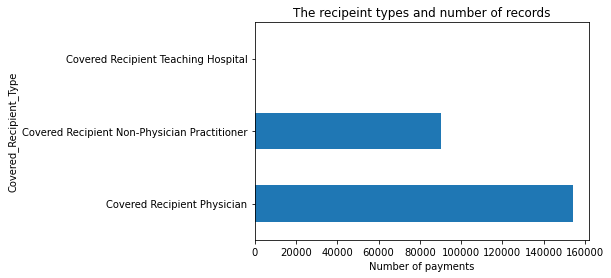

In [29]:
# Covered recipient types and numer of payment records
plt.title('The recipeint types and number of records');
df_mycom['Covered_Recipient_Type'].value_counts().plot(kind='barh')
plt.xlabel('Number of payments');


In [30]:
# Recipient types and total amount pain to each type
df_mycom.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().reset_index()


,Covered_Recipient_Type,Total_Amount_of_Payment_USDollars
0,Covered Recipient Non-Physician Practitioner,2566318.11
1,Covered Recipient Physician,18457300.06
2,Covered Recipient Teaching Hospital,2476309.09


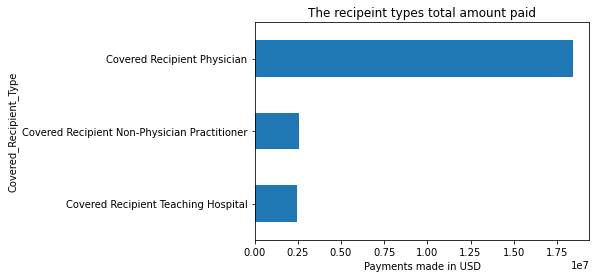

In [31]:
# Covered recipient types and payment amount

plt.title('The recipeint types total amount paid');
df_mycom.groupby('Covered_Recipient_Type')['Total_Amount_of_Payment_USDollars'].sum().sort_values().plot(kind='barh')
plt.xlabel('Payments made in USD');


In [32]:
# Payment to teaching hospitals
print("The number of teaching hospitals paid:", df_mycom['Teaching_Hospital_Name'].nunique())


The number of teaching hospitals paid: 105


In [33]:
# Teaching hospitals and related paymants
top_teaching=df_mycom.groupby(['Covered_Recipient_Type', 'Teaching_Hospital_Name'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_teaching.Teaching_Hospital_Name.describe()



count                                105
unique                               105
top       rush university medical center
freq                                   1
Name: Teaching_Hospital_Name, dtype: object

In [34]:
# Teaching hospitals sorted by total payment amount
print("Teaching hospitals and total payments")
top_teaching


Teaching hospitals and total payments


,Covered_Recipient_Type,Teaching_Hospital_Name,Total_Amount_of_Payment_USDollars
0,Covered Recipient Teaching Hospital,rush university medical center,748045.0
1,Covered Recipient Teaching Hospital,hospital of the univ of penna,720100.0
2,Covered Recipient Teaching Hospital,university of washington med ctr,133350.0
3,Covered Recipient Teaching Hospital,montefiore medical center,115000.0
4,Covered Recipient Teaching Hospital,massachusetts general hospital,88500.0
...,...,...,...
100,Covered Recipient Teaching Hospital,princeton healthcare system,500.0
101,Covered Recipient Teaching Hospital,our lady of the lake rmc,500.0
102,Covered Recipient Teaching Hospital,southwest general health center,500.0
103,Covered Recipient Teaching Hospital,methodist medical ctr of illinois,450.0


In [35]:
# identifying unique individuals using profile ID.
print("Total individuals by profile paid:", df_mycom['Covered_Recipient_Profile_ID'].nunique())



Total individuals by profile paid: 100402


In [36]:
print("Gender distribution in healthcare dataset")
gender_dist=df_mycom.groupby(['Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist



Gender distribution in healthcare dataset


,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,F,50789
1,M,49608


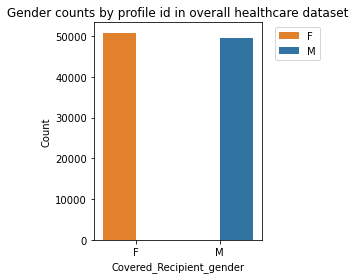

In [37]:
# Plot for gender distribution
my_palette ={"F": "C1", "M": "C0"}
g=sns.barplot(data=gender_dist, x='Covered_Recipient_gender', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender counts by profile id in overall healthcare dataset")
g.figure.set_size_inches(3, 4)
plt.ylabel("Count")
# Place the legend outside the plot
plt.xticks
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [38]:
print("Gender distribution by physicians and non-physicians in Covered recipients")
gender_dist_recipients=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_recipients

Gender distribution by physicians and non-physicians in Covered recipients


,Covered_Recipient_Type,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Covered Recipient Non-Physician Practitioner,F,30210
1,Covered Recipient Non-Physician Practitioner,M,9174
2,Covered Recipient Physician,F,20579
3,Covered Recipient Physician,M,40434


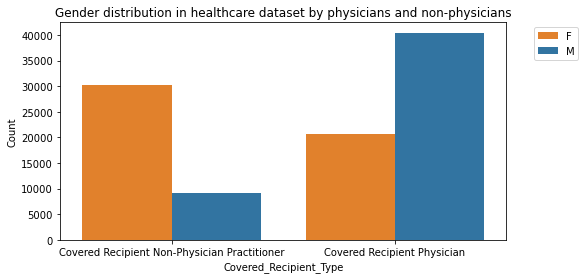

In [39]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_recipients, x='Covered_Recipient_Type', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution in healthcare dataset by physicians and non-physicians")
g.figure.set_size_inches(8, 4)
plt.ylabel("Count")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [40]:
print("Gender distribution amongst physician categories")
gender_dist_physicians=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_physicians



Gender distribution amongst physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Chiropractor,F,1
1,Chiropractor,M,1
2,Doctor of Dentistry,F,9
3,Doctor of Dentistry,M,12
4,Doctor of Optometry,F,4
5,Doctor of Optometry,M,2
6,Doctor of Osteopathy,F,221
7,Doctor of Osteopathy,M,319
8,Doctor of Podiatric Medicine,F,11
9,Doctor of Podiatric Medicine,M,41


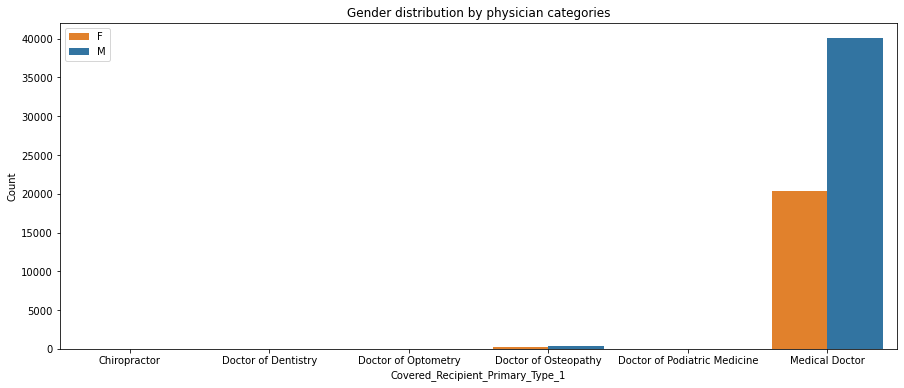

In [41]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_physicians, x='Covered_Recipient_Primary_Type_1', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution by physician categories")
g.figure.set_size_inches(15, 6)
plt.ylabel("Count")
# Place the legend outside the plot
plt.legend(loc='upper left');



In [42]:
print("Gender distribution amongst non-physician categories")
gender_dist_non_physicians=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Non-Physician Practitioner'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Covered_Recipient_Profile_ID'].nunique().reset_index()
gender_dist_non_physicians



Gender distribution amongst non-physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Covered_Recipient_Profile_ID
0,Anesthesiologist Assistant,F,1
1,Certified Nurse-Midwife,F,4
2,Certified Registered Nurse Anesthetist,F,198
3,Certified Registered Nurse Anesthetist,M,232
4,Clinical Nurse Specialist,F,1
5,Clinical Nurse Specialist,M,1
6,Nurse Practitioner,F,24137
7,Nurse Practitioner,M,6575
8,Physician Assistant,F,5869
9,Physician Assistant,M,2366


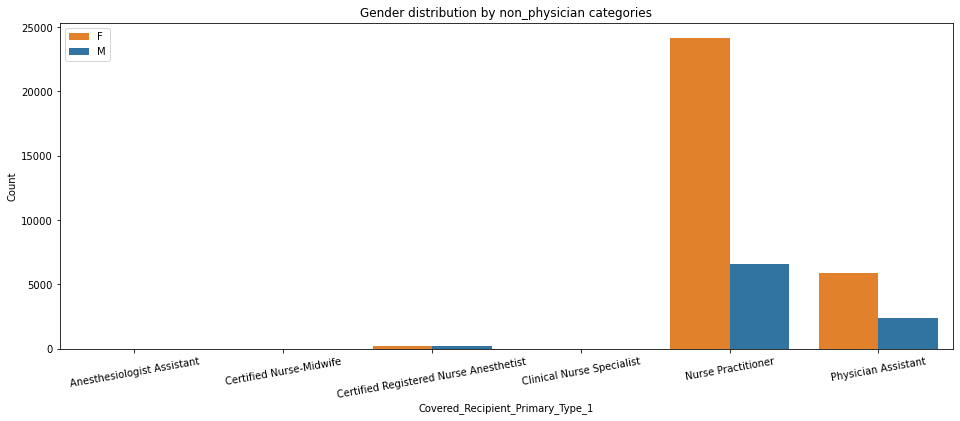

In [43]:
# Plot for gender distribution
g=sns.barplot(data=gender_dist_non_physicians, x='Covered_Recipient_Primary_Type_1', y='Covered_Recipient_Profile_ID', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution by non_physician categories")
g.figure.set_size_inches(16, 6)
plt.ylabel("Count")
plt.xticks(rotation=10)
# Place the legend outside the plot
plt.legend(loc='upper left');



In [44]:
# Covered recipient types and total payments to each type by gender
print("Total payments by recipients gender")
recipient_gender_payments=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index();
recipient_gender_payments


Total payments by recipients gender


,Covered_Recipient_Type,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Covered Recipient Physician,M,14021856.62
1,Covered Recipient Physician,F,4435369.16
2,Covered Recipient Non-Physician Practitioner,F,2098441.39
3,Covered Recipient Non-Physician Practitioner,M,467846.15


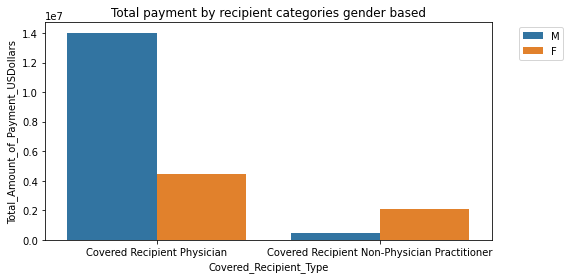

In [45]:
# Plot for gender distribution
g=sns.barplot(data=recipient_gender_payments, x='Covered_Recipient_Type', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by recipient categories gender based")
g.figure.set_size_inches(8, 4)

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



## Total payment physicians 

In [46]:
### Total payment split physician profiles
print("The total payment for physician profiles")
physicians_total_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
physicians_total_payments



The total payment for physician profiles


,Covered_Recipient_Primary_Type_1,Total_Amount_of_Payment_USDollars
0,Medical Doctor,18417621.38
1,Doctor of Osteopathy,34971.66
2,Doctor of Dentistry,2926.63
3,Doctor of Podiatric Medicine,1518.83
4,Doctor of Optometry,211.02
5,Chiropractor,50.54


In [47]:
### Total payment split physician profiles by gender
print("The total payment for physician profiles")
physicians_gender_total_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1', 'Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
physicians_gender_total_payments



The total payment for physician profiles


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Medical Doctor,M,13998452.72
1,Medical Doctor,F,4419094.38
2,Doctor of Osteopathy,M,21386.37
3,Doctor of Osteopathy,F,13585.29
4,Doctor of Dentistry,F,2171.81
5,Doctor of Podiatric Medicine,M,1209.07
6,Doctor of Dentistry,M,754.82
7,Doctor of Podiatric Medicine,F,309.76
8,Doctor of Optometry,F,172.12
9,Doctor of Optometry,M,38.90


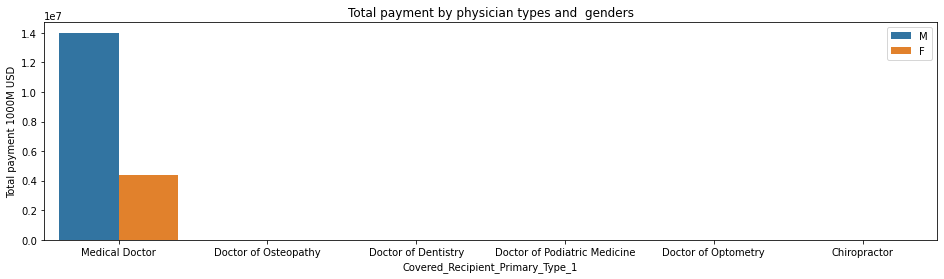

In [48]:
# Plot for gender distribution
g=sns.barplot(data=physicians_gender_total_payments, x='Covered_Recipient_Primary_Type_1', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Total payment by physician types and  genders")
g.figure.set_size_inches(16, 4)
plt.ylabel("Total payment 1000M USD")
# Place the legend outside the plot
plt.legend( loc='upper right');



## Average payments

In [49]:
# Average payment per recipient type.
print("The average payment by per transaction recipient category")
avg=df_mycom.groupby(['Covered_Recipient_Type'])['Average_payment'].mean()
avg


The average payment by per transaction recipient category


Covered_Recipient_Type
Covered Recipient Non-Physician Practitioner       28.390359
Covered Recipient Physician                       119.559909
Covered Recipient Teaching Hospital             10492.835127
Name: Average_payment, dtype: float64

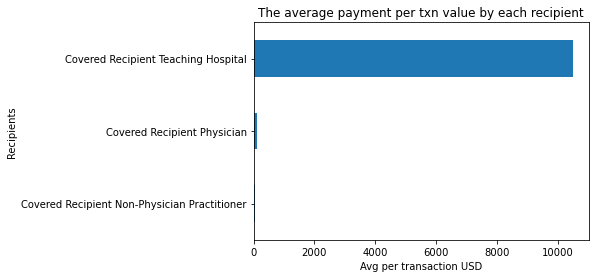

In [50]:
## Plot for average payment per recipient group type
plt.title("The average payment per txn value by each recipient")
avg.plot(kind='barh')
plt.xlabel('Avg per transaction USD')
plt.ylabel('Recipients');


In [51]:
##  Average payment per recipient physician primary 1 type gender based
print('Gender based average per transaction payment  for recipient types')
gender_recipients_avg=df_mycom.groupby(['Covered_Recipient_Type','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
   
gender_recipients_avg



Gender based average per transaction payment  for recipient types


,Covered_Recipient_Type,Covered_Recipient_gender,Average_payment
0,Covered Recipient Physician,M,127.688494
1,Covered Recipient Physician,F,99.537010
2,Covered Recipient Non-Physician Practitioner,F,30.067076
3,Covered Recipient Non-Physician Practitioner,M,22.710978


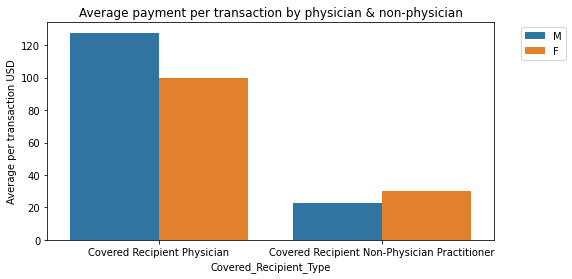

In [52]:
# Plot for gender distribution
g=sns.barplot(data=gender_recipients_avg, x='Covered_Recipient_Type', y='Average_payment', hue='Covered_Recipient_gender', palette=my_palette).set_title("Average payment per transaction by physician & non-physician")
g.figure.set_size_inches(8, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');



In [53]:
##  Average payment per recipient physician primary 1 type gender based
print('Gender based average transaction value for physician categories')
gender_recipients_avg_payments=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Primary_Type_1','Covered_Recipient_gender'])['Average_payment'].mean().sort_values(ascending=False).reset_index()
gender_recipients_avg_payments



Gender based average transaction value for physician categories


,Covered_Recipient_Primary_Type_1,Covered_Recipient_gender,Average_payment
0,Doctor of Dentistry,F,167.062308
1,Medical Doctor,M,128.155751
2,Medical Doctor,F,100.047416
3,Doctor of Dentistry,M,44.401176
4,Doctor of Optometry,F,43.030000
5,Doctor of Osteopathy,M,42.265553
6,Doctor of Osteopathy,F,37.736917
7,Chiropractor,F,35.800000
8,Doctor of Podiatric Medicine,F,25.813333
9,Doctor of Podiatric Medicine,M,21.211754


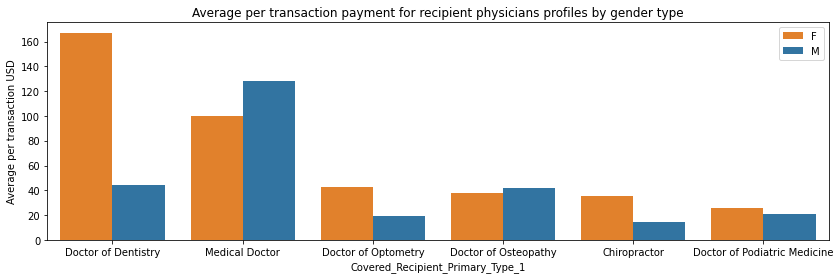

In [54]:
## Plot for average payment per recipient physician primary 1 type
g=sns.barplot(data=gender_recipients_avg_payments, x='Covered_Recipient_Primary_Type_1', y='Average_payment', hue='Covered_Recipient_gender',palette=my_palette)
g.set_title('Average per transaction payment for recipient physicians profiles by gender type')
g.figure.set_size_inches(14, 4)
plt.ylabel("Average per transaction USD")
# Place the legend outside the plot
plt.legend( loc='upper right');



## Analysis by individuals

In [55]:
print("Total payment distribution per individual")
ind_tot_payments=df_mycom[df_mycom['Covered_Recipient_Profile_ID'].notna()].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
ind_tot_payments


Total payment distribution per individual


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,176541.0,M,417266.50
1,10883123.0,F,271572.68
2,647291.0,F,254100.00
3,1215869.0,F,148839.32
4,190953.0,F,137381.73
...,...,...,...
100392,869045.0,F,5.75
100393,279230.0,M,5.51
100394,1382633.0,M,5.38
100395,930543.0,F,5.30


In [56]:
### Physicians 
print("individual payment distribution")
ind_payments_phys=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
ind_payments_phys


individual payment distribution


,Covered_Recipient_Profile_ID,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,176541.0,M,417266.50
1,647291.0,F,254100.00
2,1215869.0,F,148839.32
3,190953.0,F,137381.73
4,89472.0,M,124711.11
...,...,...,...
61008,869045.0,F,5.75
61009,279230.0,M,5.51
61010,1382633.0,M,5.38
61011,930543.0,F,5.30


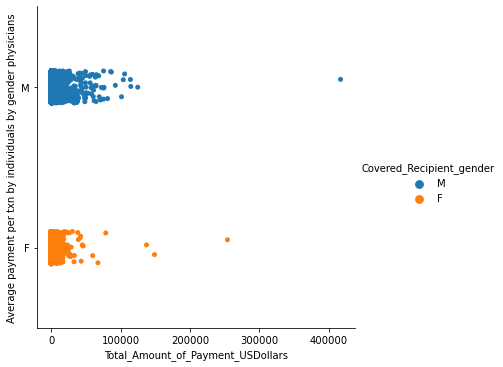

In [57]:
### Plot for gender distribution for physicians
g=sns.catplot(data=ind_payments_phys, y='Covered_Recipient_gender', x='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette)
g.set_titles("{col_name} {col_var}")
plt.ylabel("Average payment per txn by individuals by gender physicians");


#### Analysing top 50 individuals by gender

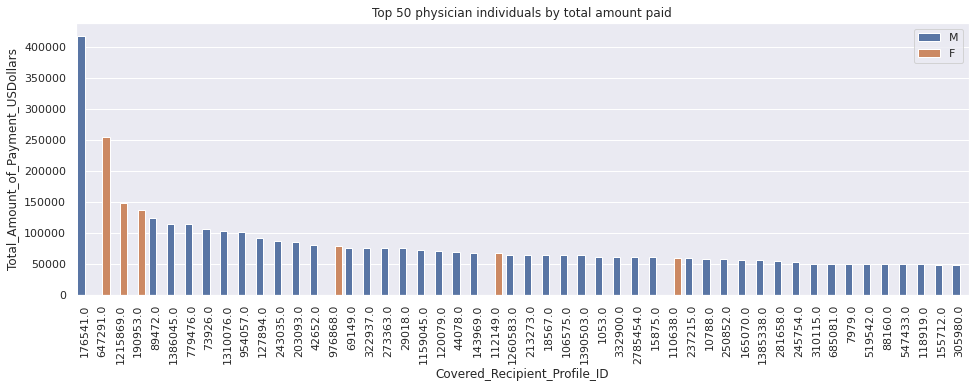

In [58]:
sns.set_theme(rc={'figure.figsize':(16,5)})
g=sns.barplot(data=ind_payments_phys[:50], x='Covered_Recipient_Profile_ID', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', 
              order=ind_payments_phys[:50].sort_values('Total_Amount_of_Payment_USDollars', ascending=False).Covered_Recipient_Profile_ID, palette=my_palette)
g.set(title="Top 50 physician individuals by total amount paid")
g.set_xticklabels(g.get_xticklabels(), rotation=90);
# Place the legend outside the plot
plt.legend(loc='upper right');

## Distribution by nature of payments

In [59]:
# Distribution by nature of payments to physicians
nature_payments=df_mycom.groupby(['Nature_of_Payment_or_Transfer_of_Value'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_payments


,Nature_of_Payment_or_Transfer_of_Value,Total_Amount_of_Payment_USDollars
0,Consulting Fee,6874874.80
1,Other_services,5968359.00
2,Food and Beverage,4961952.47
3,Travel and Lodging,3128996.04
4,Grant,1798648.21
5,Spacerent_teaching_hosp,432369.09
6,Royalty or License,294775.00
7,Education,39952.65


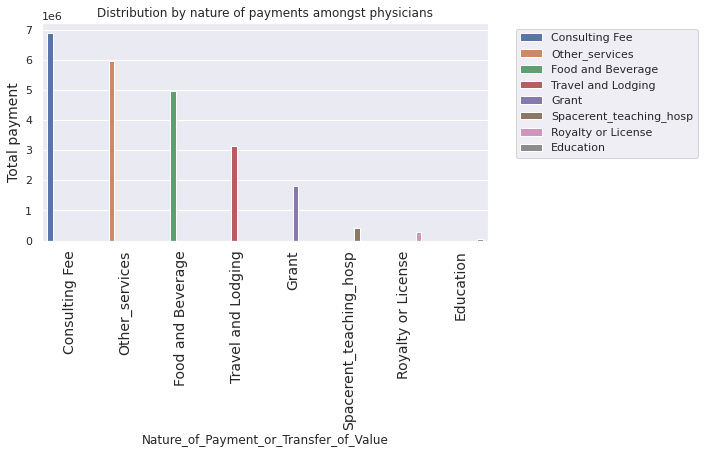

In [60]:
# Nature of payments made
g=sns.barplot(data=nature_payments, x='Nature_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Nature_of_Payment_or_Transfer_of_Value').set_title("Distribution by nature of payments amongst physicians")
g.figure.set_size_inches(8, 4)
plt.ylabel("Total payment", size=14)
plt.xticks(rotation=90, size=14)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');


In [61]:
# Distribution by gender for nature of payments
nature_gender=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Nature_of_Payment_or_Transfer_of_Value','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_gender


,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,Consulting Fee,M,4952735.82
1,Other_services,M,4552586.40
2,Food and Beverage,M,2211496.43
3,Travel and Lodging,M,2201615.18
4,Consulting Fee,F,1805908.19
5,Other_services,F,942239.72
6,Food and Beverage,F,907449.90
7,Travel and Lodging,F,730526.80
8,Grant,M,72253.21
9,Royalty or License,F,33480.00


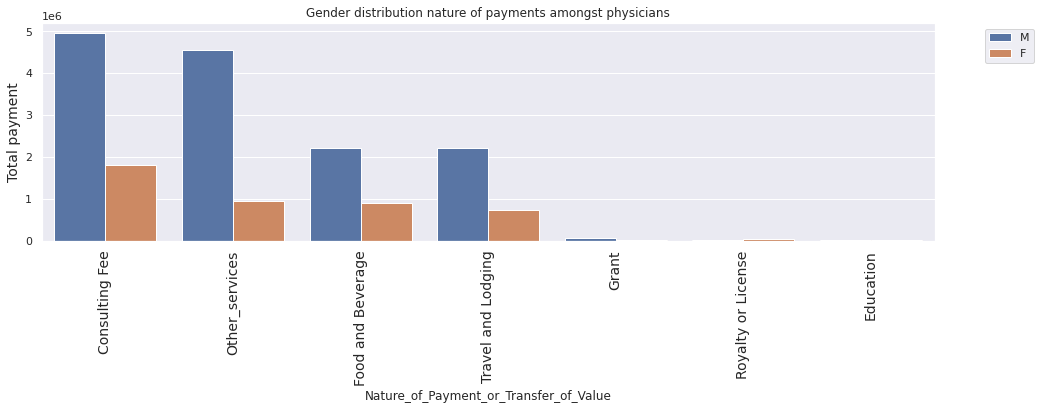

In [62]:
my_palette=my_palette ={"F": "C1", "M": "C0"}

g=sns.barplot(data=nature_gender, x='Nature_of_Payment_or_Transfer_of_Value', y='Total_Amount_of_Payment_USDollars', hue='Covered_Recipient_gender', palette=my_palette).set_title("Gender distribution nature of payments amongst physicians")
g.figure.set_size_inches(16, 4)
plt.ylabel("Total payment", size=14)
plt.xticks(rotation=90, size=14)
# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left');

In [63]:
# Distribution by gender for nature of payments
top_individual=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
top_individual

,Covered_Recipient_Profile_ID,Total_Amount_of_Payment_USDollars
0,176541.0,417266.50
1,647291.0,254100.00
2,1215869.0,148839.32
3,190953.0,137381.73
4,89472.0,124711.11
...,...,...
61011,869045.0,5.75
61012,279230.0,5.51
61013,1382633.0,5.38
61014,930543.0,5.30


In [64]:
# Distribution by gender for nature of payments
nature_gender_individual=df_mycom[df_mycom['Covered_Recipient_Type']=='Covered Recipient Physician'].groupby(['Covered_Recipient_Profile_ID','Nature_of_Payment_or_Transfer_of_Value','Covered_Recipient_gender'])['Total_Amount_of_Payment_USDollars'].sum().sort_values(ascending=False).reset_index()
nature_gender_individual


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,176541.0,Consulting Fee,M,413235.35
1,647291.0,Consulting Fee,F,254100.00
2,1215869.0,Consulting Fee,F,148839.32
3,1386045.0,Consulting Fee,M,114680.00
4,779476.0,Consulting Fee,M,114128.00
...,...,...,...,...
63459,4776462.0,Food and Beverage,F,5.30
63460,930543.0,Food and Beverage,F,5.30
63461,650330.0,Food and Beverage,F,4.46
63462,246232.0,Food and Beverage,M,4.43


In [65]:
## No 1 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']=='176541.0']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
0,176541.0,Consulting Fee,M,413235.35
1001,176541.0,Travel and Lodging,M,3990.76
25368,176541.0,Food and Beverage,M,40.39


In [66]:
## No 2 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']=='647291.0']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
1,647291.0,Consulting Fee,F,254100.0


In [67]:
## No 3 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']=='1215869.0']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
2,1215869.0,Consulting Fee,F,148839.32


In [68]:
## No 4 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']=='190953.0']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
9,190953.0,Consulting Fee,F,64130.00
30,190953.0,Travel and Lodging,F,47812.26
109,190953.0,Other_services,F,23775.00
1541,190953.0,Food and Beverage,F,1664.47


In [69]:
# No 5 receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']=='89472.0']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
11,89472.0,Travel and Lodging,M,63620.67
14,89472.0,Other_services,M,58590.00
1739,89472.0,Food and Beverage,M,1337.94
1865,89472.0,Consulting Fee,M,1162.50


In [70]:
## Reveivers of royalty
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Royalty or License']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
61,1139692.0,Royalty or License,F,33480.0
385,73266.0,Royalty or License,M,10000.0


In [71]:
# No 1 royalty receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']=='1139692.0']

,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
61,1139692.0,Royalty or License,F,33480.0
767,1139692.0,Consulting Fee,F,5512.5


In [72]:
# Receivers of grant
nature_gender_individual[nature_gender_individual['Nature_of_Payment_or_Transfer_of_Value']=='Grant']


,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
23,519542.0,Grant,M,50000.00
770,1176430.0,Grant,M,5500.00
820,893798.0,Grant,M,5250.00
902,11465259.0,Grant,F,4650.00
988,11313937.0,Grant,F,4100.00
1000,704600.0,Grant,M,4000.00
1027,7837612.0,Grant,M,3750.00
1046,11439330.0,Grant,M,3570.00
4915,270777.0,Grant,M,183.21


In [73]:
# No 1 royalty receiver
nature_gender_individual[nature_gender_individual['Covered_Recipient_Profile_ID']=='519542.0']

,Covered_Recipient_Profile_ID,Nature_of_Payment_or_Transfer_of_Value,Covered_Recipient_gender,Total_Amount_of_Payment_USDollars
23,519542.0,Grant,M,50000.0


# Summary of observations for Merck
* Top level gender ratio is nearly balanced. Females at 50.5%

**Physicians**
* The female count at physician level is approximately half of male count. (33% females)
* Average payment as phycians for males is higher than females.
* Average payment for males are higher as Medical doctor and osteopath. As dentists, optometerists, chirppratcer, and podiatrician female physicians get paid more on average per transaction value. 

**Non Physicians**
* Gender ratio is reversed. Females are more, females are 76.7%
* Non-physicians females get paid higher on average. 

**Amongst top 50 paid, only 6 are females.**
* Top earners are primarily paid for consultancy. With topmost to male, followed by two females.
* Royalties were paid to two individuals, topmost was female followed by male. ($33,480 and $10,000)
* Grants were paid to 7 males and 2 females amounting to $4000 approx, highest grant of $50,000 was paid to male.